In [1]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time

#%matplotlib widget
#plt.close('all')

## Load dataset

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


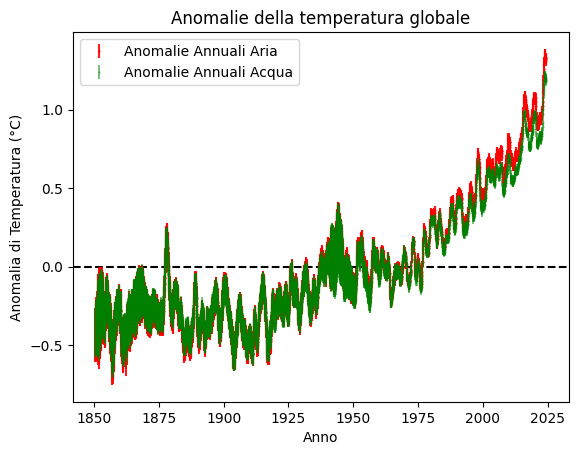

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

plt.Figure(figsize=(10, 6))
plt.errorbar(data_air['time_years'], data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.r', markersize=1, zorder=1, alpha=0.9, label='Anomalie Annuali Aria')
plt.errorbar(data_water['time_years'], data_water['Annual_Anomaly'], yerr=data_water['Annual_Anomaly_Unc'], fmt='.g', markersize=1, zorder=2, alpha=0.5, label='Anomalie Annuali Acqua')
plt.xlabel('Anno')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Anomalie della temperatura globale')
plt.axhline(0, color='black', linestyle='--', zorder=0)
plt.legend()
plt.show()

## Models definition

In [3]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [4]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

## Ultranest 

In [8]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}



for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, full_data in datasets.items(): # Ho rinominato data in full_data per chiarezza
        
        # --- MODIFICA QUI ---
        # Seleziona un dato ogni 12
        if isinstance(full_data, dict):
            data = {k: v[::12] for k, v in full_data.items()}
        else:
            data = full_data[::12]

        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()} (Downsampled 1/12)")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=300)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST (Downsampled 1/12)
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+03  867.83 [-6867.8353..-6867.8353]*| it/evals=3120/3543 eff=96.2072% N=300 0 0 0 
[ultranest] Likelihood function evaluations: 3561
[ultranest]   logZ = -6875 +- 0.131
[ultranest] Effective samples strategy satisfied (ESS = 925.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.13 tail:0.03 total:0.13 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -6874.870 +- 0.322
  single instance: logZ = -6874.870 +- 0.148
  bootstrapped   : logZ = -6874.902 +- 0.321
  tail           : logZ = +- 0.032
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3366│ ▁ ▁▁▁▁▁▂▂▃▅▆▅▇▇▇▇▆▇▆▆▄▃▂▂▁▁▁▁▁▁▁▁   ▁ │0.3664    0.3497 +- 0.0034

STARTING RUN: WATER_CONST (Downsampled 1/12)
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-6e+03  267.85 [-6267.8485..-6267.8484]*| it/evals=3180/3634 eff=95.3809% N=300   0 0 
[ultranest] Likelihood function evaluations: 3657
[ultranest]   logZ = -6275 +- 0.1135
[ultranest] Effective samples strategy satisfied (ESS = 946.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -6275.169 +- 0.254
  single instance: logZ = -6275.169 +- 0.151
  bootstrapped   : logZ = -6275.143 +- 0.252
  tail           : logZ = +- 0.034
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3058│ ▁  ▁ ▁▁▁▁▁▂▂▃▄▄▅▇▇▇▇▇▇▇▆▅▅▃▂▂▁▁▁▁▁▁▁▁ │0.3338    0.3207 +- 0.0034

STARTING RUN: AIR_LINEAR (Downsampled 1/12)
[ultranest] Sampling 300 live points from prior ..

[ultranest] Explored until L=-2e+03  722.14 [-1722.1453..-1722.1453]*| it/evals=6600/9251 eff=73.7348% N=300 0   0   0 0    
[ultranest] Likelihood function evaluations: 9265
[ultranest]   logZ = -1740 +- 0.1619
[ultranest] Effective samples strategy satisfied (ESS = 1194.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -1739.574 +- 0.368
  single instance: logZ = -1739.574 +- 0.234
  bootstrapped   : logZ = -1739.584 +- 0.368
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009599│ ▁▁ ▁▁▁▁▁▁▁▁▂▂▄▅▅▇▇▇▇▇▇▆▇▄▅▃▂▂▂▁▁▁▁▁▁▁ │0.010386    0.010019 +- 0.000095
    b                   : -1.016│ ▁▁▁▁▁▁▂▁▂▃▃▄▅▆▇▇▇▇▆▆▅▆▄▃▂▂▂▁▁▁▁▁▁ ▁ ▁ │-0.90

[ultranest] Explored until L=-2e+03  556.61 [-1556.6197..-1556.6196]*| it/evals=6600/9291 eff=73.4067% N=300 0   0  0  0 0  
[ultranest] Likelihood function evaluations: 9307
[ultranest]   logZ = -1574 +- 0.1732
[ultranest] Effective samples strategy satisfied (ESS = 1160.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -1574.037 +- 0.379
  single instance: logZ = -1574.037 +- 0.234
  bootstrapped   : logZ = -1574.019 +- 0.379
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.008803│ ▁▁▁▁▁▁▁▁▁▂▃▂▄▅▅▆▆▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁▁ ▁ │0.009501    0.009148 +- 0.000088
    b                   : -0.948│ ▁ ▁▁▁▁▁▁▁▁▁▁▃▄▅▅▅▇▇▇▇▆▆▆▄▄▃▂▁▁▁▁▁▁▁▁▁ │-0.

[ultranest] Explored until L=-2e+02  .87 [-198.9299..-198.9298]*| it/evals=10440/20281 eff=52.2496% N=300   0   00    0   0   
[ultranest] Likelihood function evaluations: 20281
[ultranest]   logZ = -229.1 +- 0.2109
[ultranest] Effective samples strategy satisfied (ESS = 1413.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.21, need <0.5)
[ultranest]   logZ error budget: single: 0.31 bs:0.21 tail:0.01 total:0.21 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -229.100 +- 0.395
  single instance: logZ = -229.100 +- 0.309
  bootstrapped   : logZ = -229.124 +- 0.395
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0000942│ ▁ ▁▁▁▁▁▁▁▁▂▄▃▅▅▆▆▇▇▇▆▅▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁ │0.0001111    0.0001024 +- 0.0000020
    b                   : -0.01330│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▆▇▇▇▇▅▅▄▄▃▂▂▁▁▁▁▁▁

[ultranest] Explored until L=-2e+02  .33 [-187.3941..-187.3939]*| it/evals=10530/20692 eff=51.6379% N=300   0  00    0  0 0  0 
[ultranest] Likelihood function evaluations: 20716
[ultranest]   logZ = -217.8 +- 0.2254
[ultranest] Effective samples strategy satisfied (ESS = 1362.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.20 to 0.50, need <0.5)
[ultranest]   logZ error budget: single: 0.31 bs:0.23 tail:0.01 total:0.23 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -217.906 +- 0.500
  single instance: logZ = -217.906 +- 0.312
  bootstrapped   : logZ = -217.834 +- 0.500
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: 2847 iterations

    a                   : 0.0000811│ ▁▁▁▁▁▁▁▁▁▁▁▂▂▄▅▇▆▇▇▇▇▆▅▅▄▄▃▁▁▁▁▁▁▁▁▁▁ │0.0000980    0.0000898 +- 0.0000020
    b                   : -0.01153│ 

[ultranest] Explored until L=-2e+02  .45 [-160.5119..-160.5118]*| it/evals=6780/107179 eff=6.3436% N=300    0  0 0 00 0 
[ultranest] Likelihood function evaluations: 107179
[ultranest]   logZ = -178.5 +- 0.1689
[ultranest] Effective samples strategy satisfied (ESS = 1356.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.24 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -178.486 +- 0.349
  single instance: logZ = -178.486 +- 0.235
  bootstrapped   : logZ = -178.488 +- 0.349
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0216│ ▁▁▁▁▁▁▁▁▂▃▄▅▇▇▆▇▇▇▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │0.0480    0.0334 +- 0.0031
    b                   : 0.02012│ ▁▁▁▁▁▁▁▁▂▂▃▄▄▆▆▇▇▇▆▆▆▅▄▄▃▂▁▁▁▁▁▁▁ ▁▁▁ │0.02440    

[ultranest] Explored until L=-2e+02  .16 [-165.2180..-165.2179]*| it/evals=6780/72302 eff=9.4164% N=300     0  0 0  0 0  
[ultranest] Likelihood function evaluations: 72311
[ultranest]   logZ = -183.2 +- 0.1568
[ultranest] Effective samples strategy satisfied (ESS = 1420.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.11 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -183.194 +- 0.326
  single instance: logZ = -183.194 +- 0.235
  bootstrapped   : logZ = -183.191 +- 0.326
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0217│ ▁▁▁▁▁▁▁▁▂▂▃▅▅▅▇▇▇▆▆▅▅▃▃▂▂▂▁▁▁▁▁▁ ▁▁ ▁ │0.0524    0.0355 +- 0.0036
    b                   : 0.01900│ ▁▁▁▁▁▁▁▁▂▂▃▃▄▅▅▇▇▆▇▅▄▄▄▂▂▂▁▁▁▁▁▁▁▁ ▁▁ │0.02368  

## Constant fit

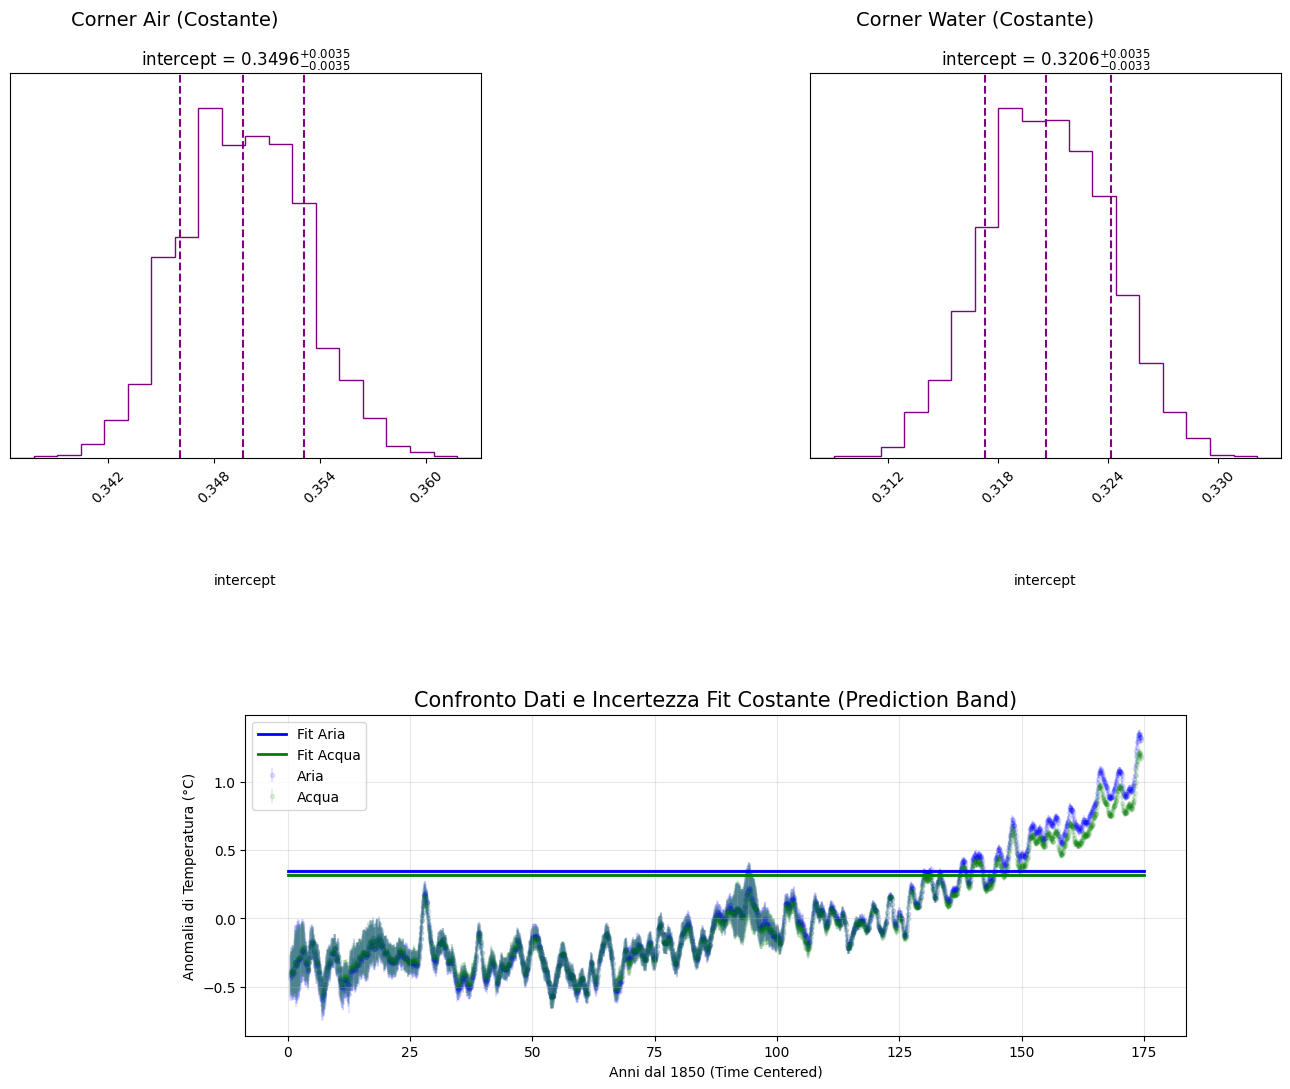

In [9]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_prefix):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label =f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Linear fit

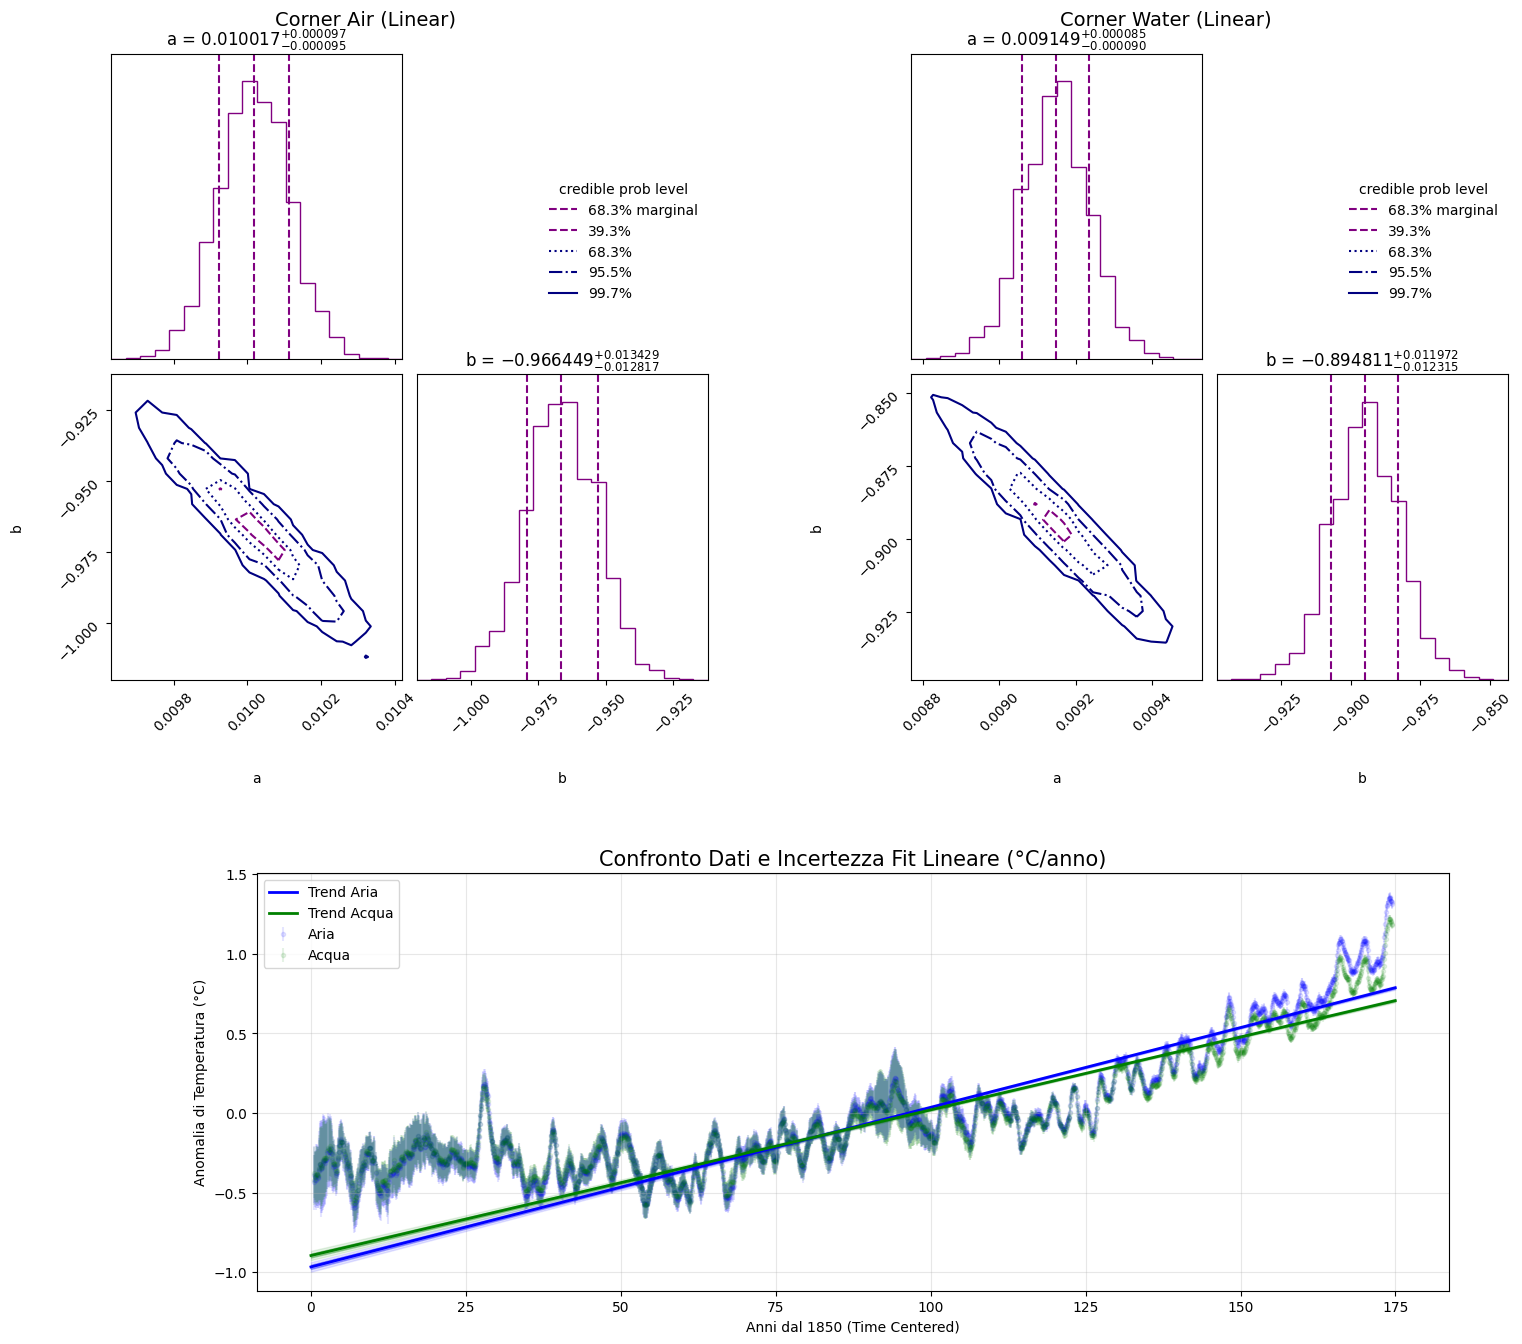

In [10]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label=f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Quadratic fit

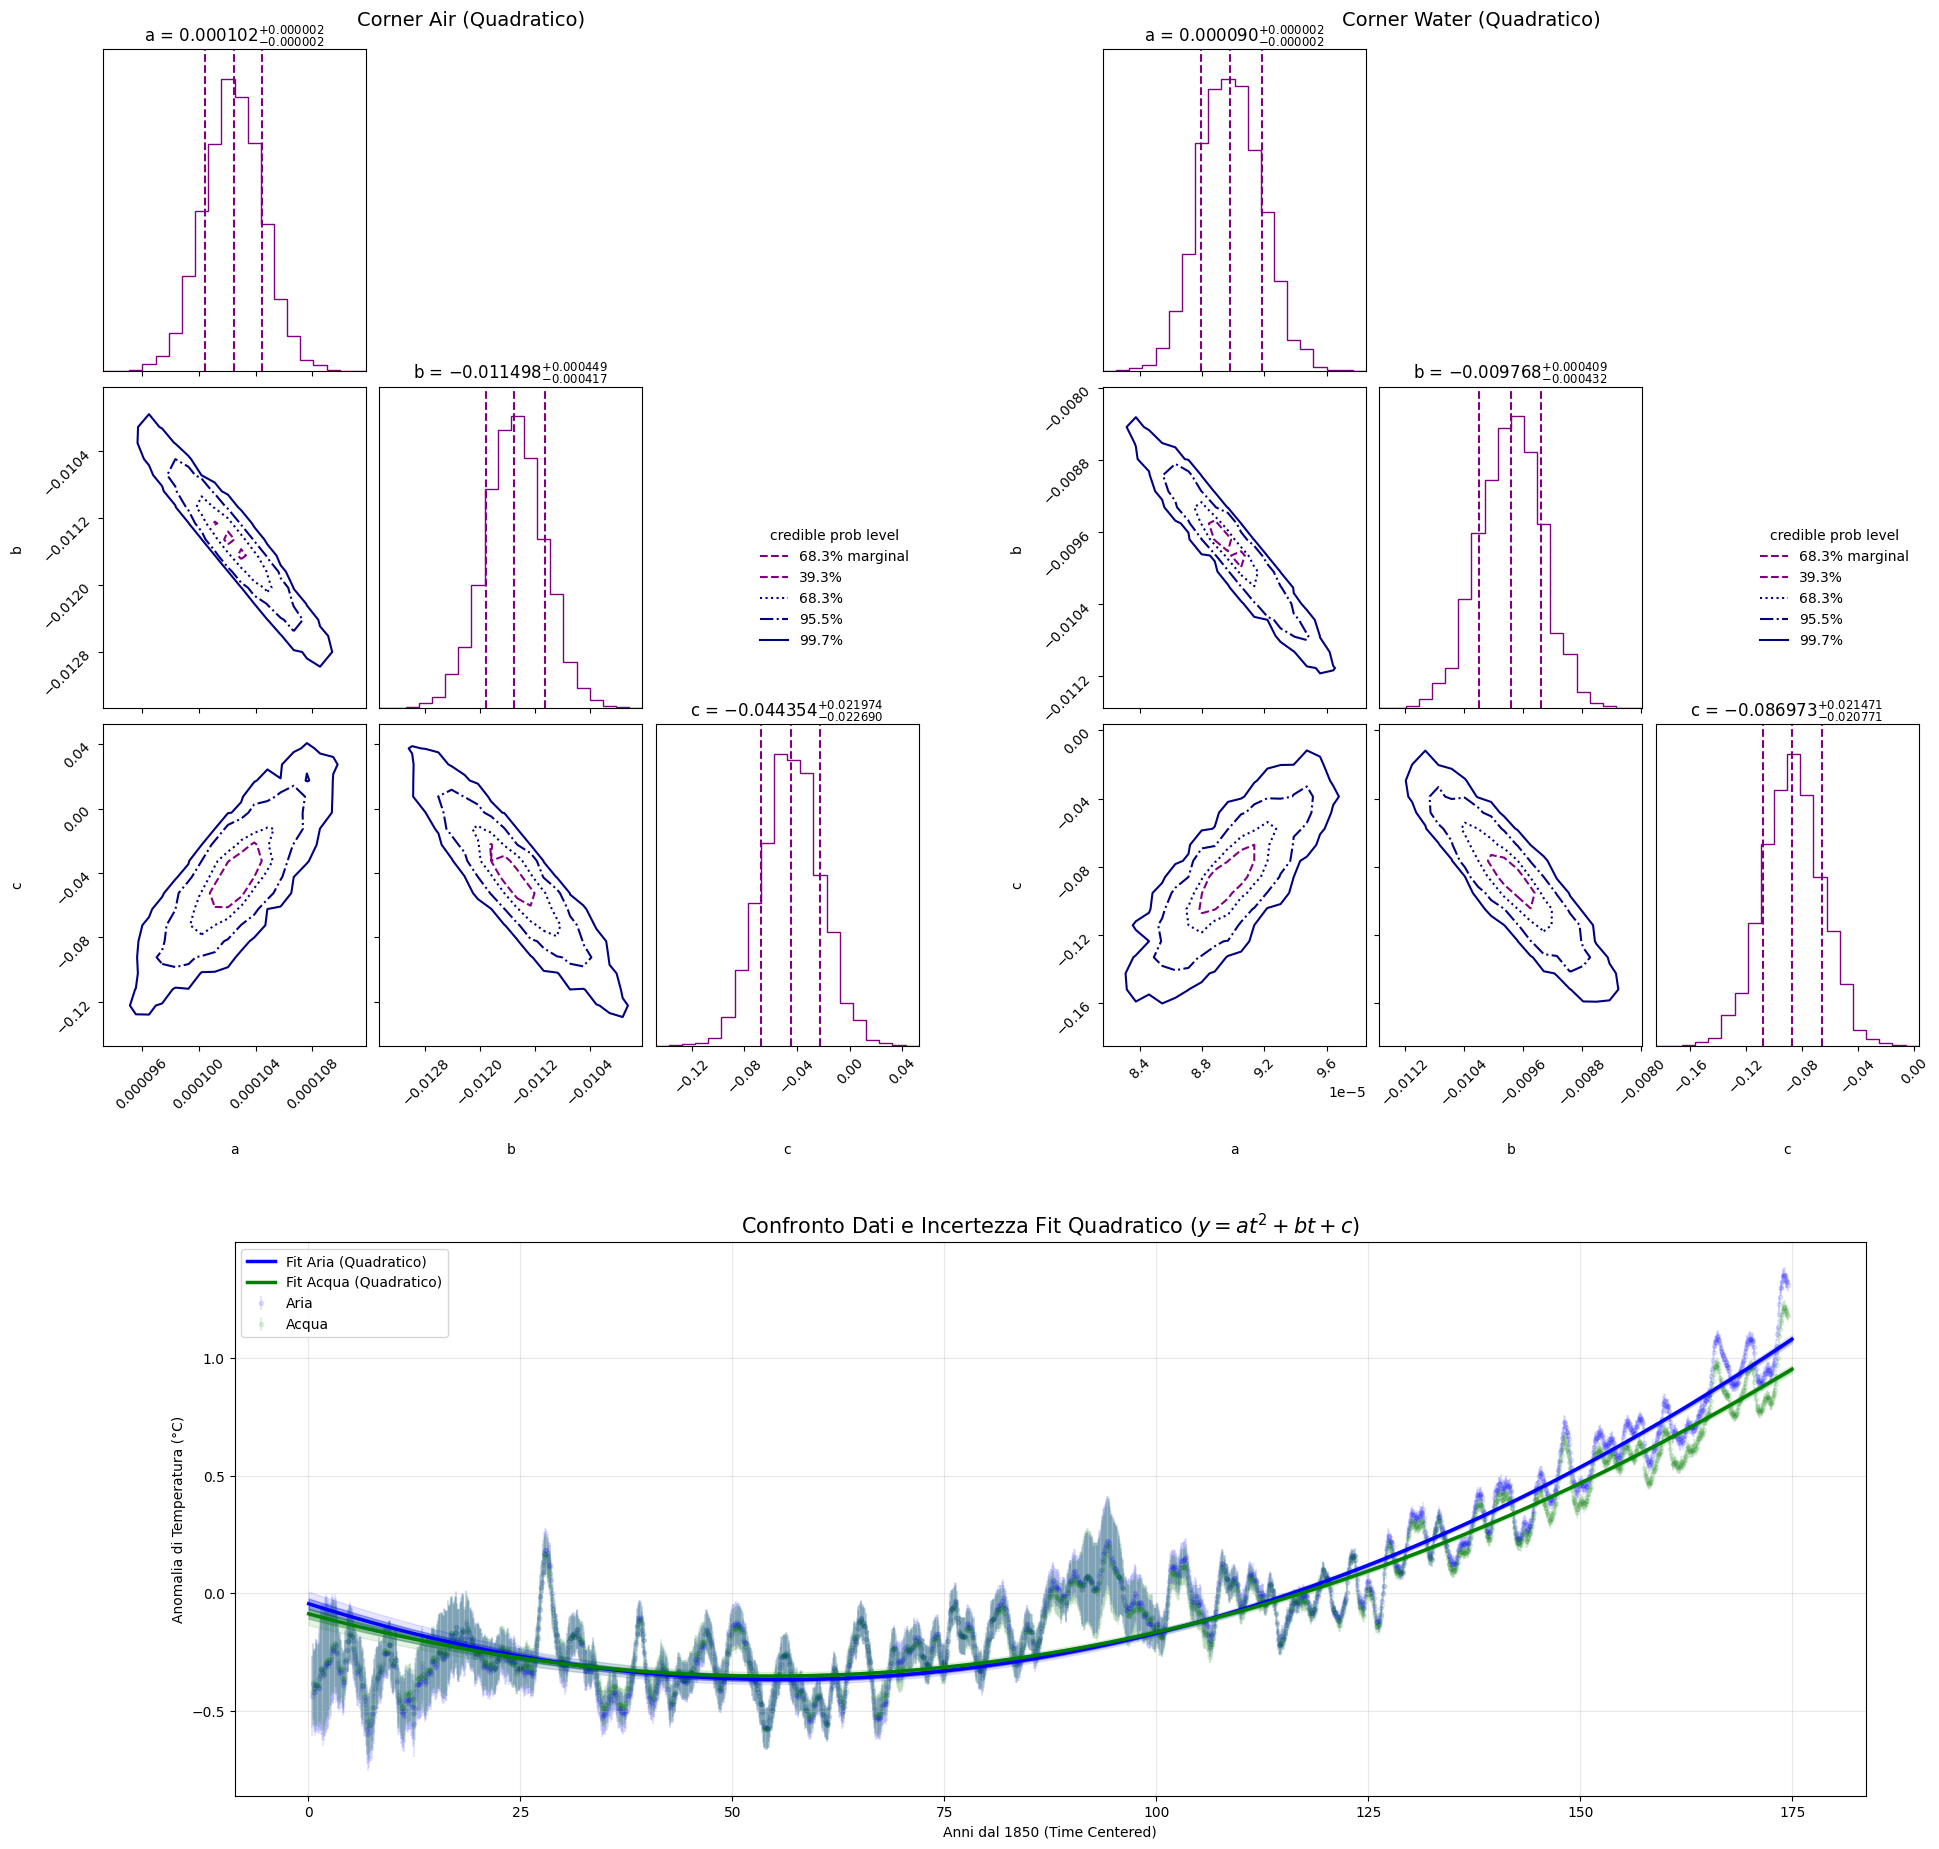

In [11]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label= f'{label_prefix}')

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Exponential fit

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_57086/3947774721.py:36: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)


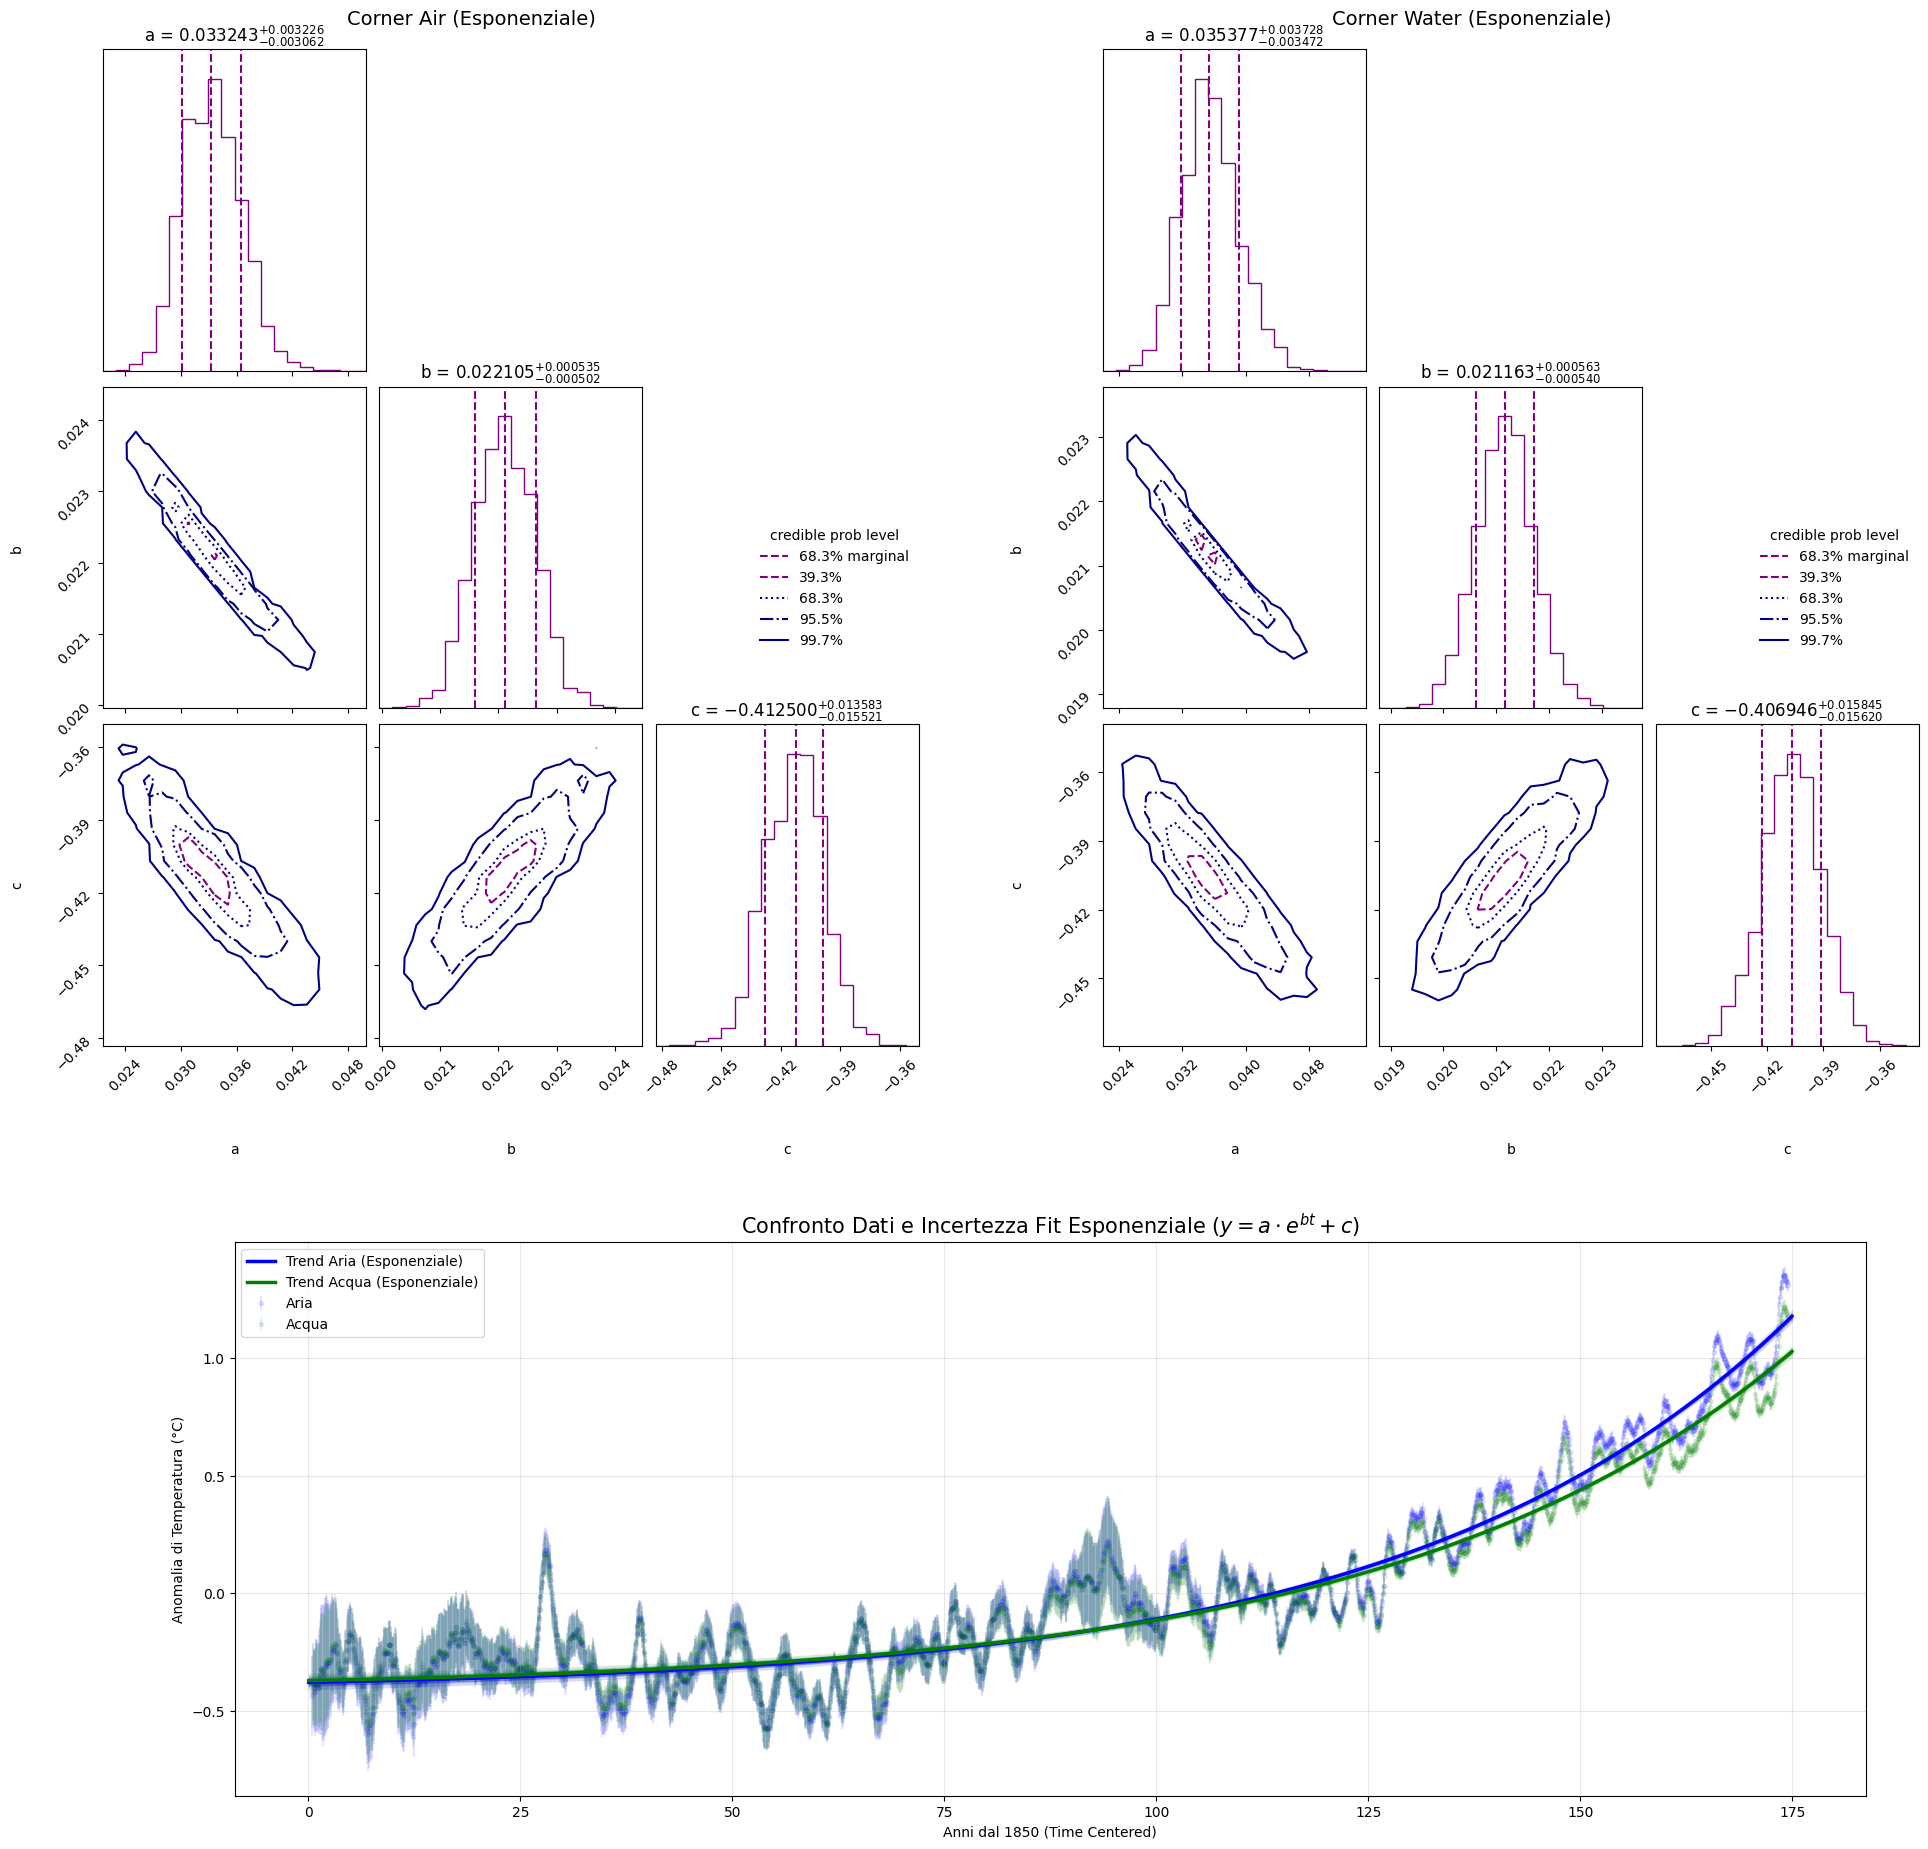

In [12]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label=f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Models comparison

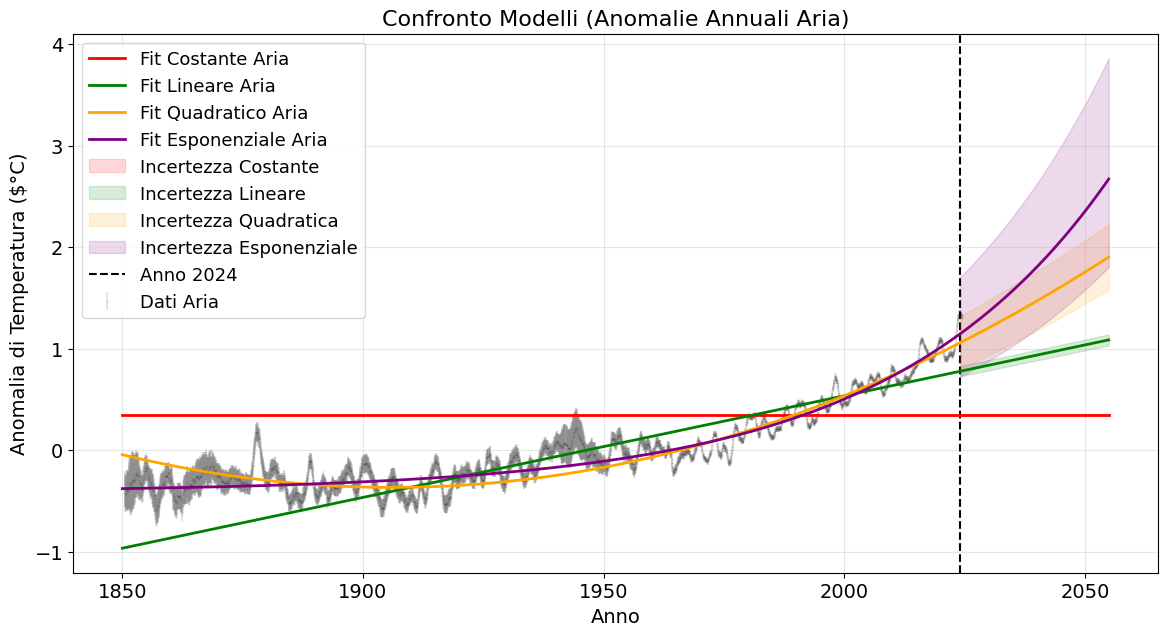

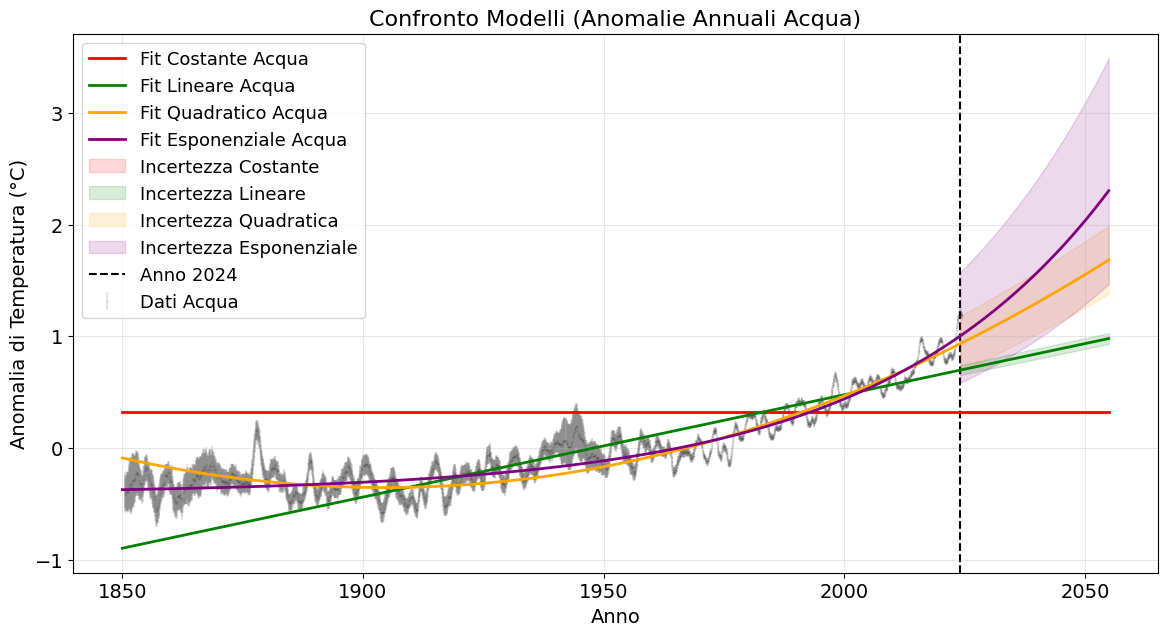

In [20]:
t_max = data_air['time_centered'].max()
t_grid = np.linspace(0 ,t_max+30, 400) 
t_grid_scaled = t_grid + 1850
# Creiamo una condizione logica: "Vero" solo per gli anni successivi all'ultimo dato
solo_futuro = t_grid_scaled >= (2024)

# --- Dati Aria ---
plt.figure(figsize=(14, 7))

plt.errorbar(data_air['time_centered']+ 1850, data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.k', markersize=1, 
             zorder=1, alpha=0.1, label='Dati Aria')
plt.plot(t_grid_scaled, constant_model(t_grid, np.median(results['air_const']['samples'])), color='red', lw=2, label='Fit Costante Aria', zorder=2)
plt.plot(t_grid_scaled, linear_model(t_grid, *np.median(results['air_linear']['samples'], axis=0)), color='green', lw=2, label='Fit Lineare Aria', zorder=2)
plt.plot(t_grid_scaled, quadratic_model(t_grid, *np.median(results['air_quadratic']['samples'], axis=0)), color='orange', lw=2, label='Fit Quadratico Aria', zorder=2)
plt.plot(t_grid_scaled, exponential_model(t_grid, *np.median(results['air_exponential']['samples'], axis=0)), color='purple', lw=2, label='Fit Esponenziale Aria', zorder=2)

plt.fill_between(t_grid_scaled, constant_model(t_grid, np.percentile(results['air_const']['samples'], 5, axis=0)), 
                 constant_model(t_grid, np.percentile(results['air_const']['samples'], 95, axis=0)),  where=solo_futuro, color='red', alpha=0.15, label='Incertezza Costante')
plt.fill_between(t_grid_scaled, linear_model(t_grid, *np.percentile(results['air_linear']['samples'], 5, axis=0)), 
                 linear_model(t_grid, *np.percentile(results['air_linear']['samples'], 95, axis=0)), where=solo_futuro, color='green', alpha=0.15, label='Incertezza Lineare')
plt.fill_between(t_grid_scaled, quadratic_model(t_grid, *np.percentile(results['air_quadratic']['samples'], 5, axis=0)), 
                 quadratic_model(t_grid, *np.percentile(results['air_quadratic']['samples'], 95, axis=0)), where=solo_futuro, color='orange', alpha=0.15, label='Incertezza Quadratica')
plt.fill_between(t_grid_scaled, exponential_model(t_grid, *np.percentile(results['air_exponential']['samples'], 5, axis=0)), 
                 exponential_model(t_grid, *np.percentile(results['air_exponential']['samples'], 95, axis=0)), where=solo_futuro, color='purple', alpha=0.15, label='Incertezza Esponenziale')

plt.axvline(2024, color='black', linestyle='--', zorder=0, label='Anno 2024')
plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura ($°C)', fontsize=14)
plt.tick_params(labelsize=14)
plt.title('Confronto Modelli (Anomalie Annuali Aria)', fontsize=16)
plt.legend(loc='upper left', fontsize=13)
plt.grid(alpha=0.3)
plt.savefig('confronto_fit_aria.png')

# --- Dati Acqua ---
plt.figure(figsize=(14, 7))

plt.errorbar(data_water['time_centered'] + 1850, data_water['Annual_Anomaly'],  yerr=data_water['Annual_Anomaly_Unc'], fmt='.k', markersize=1, 
             zorder=1, alpha=0.1, label='Dati Acqua')
plt.plot(t_grid_scaled, constant_model(t_grid, np.median(results['water_const']['samples'])), color='red', lw=2, label='Fit Costante Acqua', zorder=2)
plt.plot(t_grid_scaled, linear_model(t_grid, *np.median(results['water_linear']['samples'], axis=0)), color='green', lw=2, label='Fit Lineare Acqua', zorder=2)
plt.plot(t_grid_scaled, quadratic_model(t_grid, *np.median(results['water_quadratic']['samples'], axis=0)), color='orange', lw=2, label='Fit Quadratico Acqua', zorder=2)
plt.plot(t_grid_scaled, exponential_model(t_grid, *np.median(results['water_exponential']['samples'], axis=0)), color='purple', lw=2, label='Fit Esponenziale Acqua', zorder=2)

plt.fill_between(t_grid_scaled, constant_model(t_grid, np.percentile(results['water_const']['samples'], 5, axis=0)), 
                 constant_model(t_grid, np.percentile(results['water_const']['samples'], 95, axis=0)),  where=solo_futuro, color='red', alpha=0.15, label='Incertezza Costante')
plt.fill_between(t_grid_scaled, linear_model(t_grid, *np.percentile(results['water_linear']['samples'], 5, axis=0)), 
                 linear_model(t_grid, *np.percentile(results['water_linear']['samples'], 95, axis=0)), where=solo_futuro, color='green', alpha=0.15, label='Incertezza Lineare')
plt.fill_between(t_grid_scaled, quadratic_model(t_grid, *np.percentile(results['water_quadratic']['samples'], 5, axis=0)), 
                 quadratic_model(t_grid, *np.percentile(results['water_quadratic']['samples'], 95, axis=0)), where=solo_futuro, color='orange', alpha=0.15, label='Incertezza Quadratica')
plt.fill_between(t_grid_scaled, exponential_model(t_grid, *np.percentile(results['water_exponential']['samples'], 5, axis=0)), 
                 exponential_model(t_grid, *np.percentile(results['water_exponential']['samples'], 95, axis=0)), where=solo_futuro, color='purple', alpha=0.15, label='Incertezza Esponenziale')

plt.axvline(2024, color='black', linestyle='--', zorder=0, label='Anno 2024')
plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.tick_params(labelsize=14)
plt.title('Confronto Modelli (Anomalie Annuali Acqua)', fontsize=16)
plt.legend(loc='upper left', fontsize=13)
plt.grid(alpha=0.3)
plt.savefig('confronto_fit_acqua.png')

plt.show()


In [ ]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81425.13 |         0.00
linear          |    -20205.65 |     61219.49
quadratic       |     -2172.31 |     79252.82
exponential     |     -1703.50 |     79721.63

--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74219.88 |         0.00
linear          |    -18251.16 |     55968.73
quadratic       |     -1983.27 |     72236.61
exponential     |     -1709.50 |     72510.39

--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81425.13 |    -61219.49
linear          |    -20205.65 |         0.00
quadratic       |     -2172.31 |     18033.33
exponential     |     -1703.50 |  

In [ ]:
arr1 = data_air_masked['time_centered']
arr2 = data_air_masked['Annual_Anomaly']

corr_matrix_time_anomaly = np.corrcoef(arr1, arr2)
correlazione_time_anomaly = corr_matrix_time_anomaly[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Anomalia): {correlazione_time_anomaly:.4f}")

arr3 = data_air_masked['Annual_Anomaly_Unc']
corr_matrix_anomaly_unc = np.corrcoef(arr2, arr3)
correlazione_anomaly_unc = corr_matrix_anomaly_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): {correlazione_anomaly_unc:.4f}")

corr_matrix_time_unc = np.corrcoef(arr1, arr3)
correlazione_time_unc = corr_matrix_time_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Incertezza): {correlazione_time_unc:.4f}")

Coefficiente di correlazione di Pearson (Time vs Anomalia): 0.8581
Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): -0.5791
Coefficiente di correlazione di Pearson (Time vs Incertezza): -0.7683
